# PART A: LIBARARY MANAGEMENT SYSTEM

In [1]:
## IMPORTS FOR BOTH PARTS 
from datetime import datetime
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import ast # clear product column to get individual products
from IPython.display import Markdown ## For publishing summary in markdown format

### FUNCTIONS FOR LIBRARY MANAGEMENT

In [2]:
"""
City Library Management System
================================
All data and logic live in this single module (no sub-modules).
Data is held in three in-memory stores:
  - BOOKS      : dict keyed by book_id
  - MEMBERS    : dict keyed by member_id
  - BORROW_LOG : list of transaction records
"""

from datetime import datetime
from collections import Counter

# ---------------------------------------------------------------------------
# In-memory data stores
# ---------------------------------------------------------------------------

BOOKS: dict = {}        # {book_id: {title, author, genre, availability}}
MEMBERS: dict = {}      # {member_id: {name, age, contact, borrowed_books}}
BORROW_LOG: list = []   # [{book_id, member_id, action, timestamp}]


# ---------------------------------------------------------------------------
# Helper
# ---------------------------------------------------------------------------

def _now() -> str:
    """Return current timestamp as a formatted string."""
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

def reset_library() -> None:
    """Clear all in-memory data stores"""
    BOOKS.clear()
    MEMBERS.clear()
    BORROW_LOG.clear()

# ---------------------------------------------------------------------------
# Book Record Creation / Addition
# ---------------------------------------------------------------------------
def add_book(book_id: str, title: str, author: str, genre: str) -> dict:
    """
    Add a new book to the library.

    Parameters
    ----------
    book_id : unique identifier (e.g. 'B001')
    title   : book title
    author  : author name
    genre   : genre label (e.g. 'Fiction', 'Science')

    Returns
    -------
    The newly created book record, or raises ValueError if ID already exists.
    """
    if book_id in BOOKS:
        raise ValueError(f"Book ID '{book_id}' already exists.")

    book = {
        "book_id":      book_id,
        "title":        title.strip(),
        "author":       author.strip(),
        "genre":        genre.strip(),
        "availability": "Available",
    }
    BOOKS[book_id] = book
    return book

# ---------------------------------------------------------------------------
# Member Record Creation / Addition
# ---------------------------------------------------------------------------

def add_member(member_id: str, name: str, age: int, contact: str) -> dict:
    """
    Register a new library member.

    Parameters
    ----------
    member_id : unique identifier (e.g. 'M001')
    name      : full name
    age       : age in years (must be ≥ 5)
    contact   : email or phone number

    Returns
    -------
    The newly created member record, or 
        - raises ValueError if ID already exists
        - raises ValueError if age is less than 5
        - FUTURE: we can use a combination of name and contact to check for duplicates,
    """
    if member_id in MEMBERS:
        raise ValueError(f"Member ID '{member_id}' already exists.")
    if age < 5:
        raise ValueError("Member age must be at least 5.")

    member = {
        "member_id":      member_id,
        "name":           name.strip(),
        "age":            age,
        "contact":        contact.strip(),
        "borrowed_books": [],   # list of book_ids currently borrowed
    }
    MEMBERS[member_id] = member
    return member


# ---------------------------------------------------------------------------
# Borrow and Return System
# ---------------------------------------------------------------------------

def issue_book(member_id: str, book_id: str) -> dict:
    """
    Issue a book to a member.

    Business rules
    --------------
    - Book and member must exist.
    - Book must be 'Available'.
    - A member cannot borrow the same book twice simultaneously.

    Returns
    -------
    The borrow-log entry that was recorded.
    """
    member = get_member(member_id)
    book   = get_book(book_id)

    if book["availability"] != "Available":
        raise ValueError(
            f"Book '{book['title']}' is already issued and not available."
        )
    if book_id in member["borrowed_books"]:
        raise ValueError(
            f"Member '{member['name']}' already has book '{book['title']}'."
        )

    # Update state
    BOOKS[book_id]["availability"] = "Issued"
    MEMBERS[member_id]["borrowed_books"].append(book_id)

    entry = {
        "action":    "ISSUE",
        "member_id": member_id,
        "book_id":   book_id,
        "timestamp": _now(),
    }
    BORROW_LOG.append(entry)
    return entry


def return_book(member_id: str, book_id: str) -> dict:
    """
    Return a book previously borrowed by a member.

    Returns
    -------
    The borrow-log entry that was recorded.
    """
    member = get_member(member_id)
    book   = get_book(book_id)

    if book_id not in member["borrowed_books"]:
        raise ValueError(
            f"Member '{member['name']}' does not have book '{book['title']}'."
        )

    # Update state
    BOOKS[book_id]["availability"] = "Available"
    MEMBERS[member_id]["borrowed_books"].remove(book_id)

    entry = {
        "action":    "RETURN",
        "member_id": member_id,
        "book_id":   book_id,
        "timestamp": _now(),
    }
    BORROW_LOG.append(entry)
    return entry

def get_member(member_id: str) -> dict:
    """Return member record or raise KeyError."""
    if member_id not in MEMBERS:
        raise KeyError(f"Member ID '{member_id}' not found.")
    return MEMBERS[member_id]

def update_book_availability(book_id: str, status: str) -> dict:
    """
    Manually set the availability of a book.

    Parameters
    ----------
    book_id : target book
    status  : 'Available' or 'Issued'
    """
    if book_id not in BOOKS:
        raise KeyError(f"Book ID '{book_id}' not found.")
    if status not in ("Available", "Issued"):
        raise ValueError("Status must be 'Available' or 'Issued'.")
    BOOKS[book_id]["availability"] = status
    return BOOKS[book_id]

def get_book(book_id: str) -> dict:
    """Return book record or raise KeyError."""
    if book_id not in BOOKS:
        raise KeyError(f"Book ID '{book_id}' not found.")
    return BOOKS[book_id]

# ---------------------------------------------------------------------------
# Display Helpers 
# ---------------------------------------------------------------------------
def display_books(books: list):
    """Display all the books, related details and availability status."""
    if not books:
        print("  No records found.")
    for b in books:
        avail_tag = "[AVAILABLE]" if b["availability"] == "Available" else "[ISSUED]   "
        print(
            f"  {avail_tag} {b['book_id']} | {b['title']}"
            f" by {b['author']} | Genre: {b['genre']}"
        )

def display_members(members: list):
    """Display all the members and their details."""
    if not members:
        print("  No records found.")
    for m in members:
        borrowed = ", ".join(m["borrowed_books"]) if m["borrowed_books"] else "None"
        print(
            f"  {m['member_id']} | {m['name']} | Age: {m['age']} | Contact: {m['contact']}"
            f" | Borrowed Books: {borrowed}"
        )

In [3]:
reset_library()

# CREATE BOOK AND MEMBER RECORDS

### ADD BOOKS & TEST LIST

In [4]:
# Add individual books
books_data = pd.DataFrame([
    ("B001", "The Great Gatsby",        "F. Scott Fitzgerald", "Fiction"),
    ("B002", "1984",                    "George Orwell",       "Dystopian"),
    ("B003", "A Brief History of Time", "Stephen Hawking",     "Science"),
    ("B004", "Dune",                    "Frank Herbert",       "Science Fiction"),
    ("B005", "The Hobbit",              "J.R.R. Tolkien",      "Fantasy"),
], columns=["id", "title", "author", "genre"])

for _, row in books_data.iterrows():
    add_book(row["id"], row["title"], row["author"], row["genre"])

In [5]:
## LIST OF ALL AVAILABLE BOOKS
display_books(books = list(BOOKS.values()))

  [AVAILABLE] B001 | The Great Gatsby by F. Scott Fitzgerald | Genre: Fiction
  [AVAILABLE] B002 | 1984 by George Orwell | Genre: Dystopian
  [AVAILABLE] B003 | A Brief History of Time by Stephen Hawking | Genre: Science
  [AVAILABLE] B004 | Dune by Frank Herbert | Genre: Science Fiction
  [AVAILABLE] B005 | The Hobbit by J.R.R. Tolkien | Genre: Fantasy


In [6]:
## TESTING DUPLICATE BOOK ID

## Should fail
try:
    add_book("B001", "The Hitchhiker's Guide to the Galaxy", "Douglas Adams", "Science Fiction")
    print("Successfully added duplicate book ID 'B001' (this should fail).")
except ValueError as e:
    print(f"Error: {e}")

## Should succeed
try:
    add_book("B006", "The Hitchhiker's Guide to the Galaxy", "Douglas Adams", "Science Fiction")
    print("Successfully added book ID 'B006'.")
except ValueError as e:
    print(f"Error: {e}")

## Should succeed, multiple copies of the same book with different IDs
try:
    add_book("B007", "The Hitchhiker's Guide to the Galaxy", "Douglas Adams", "Science Fiction")
    print("Successfully added book ID 'B007'.")
except ValueError as e:
    print(f"Error: {e}")


Error: Book ID 'B001' already exists.
Successfully added book ID 'B006'.
Successfully added book ID 'B007'.


In [7]:
display_books(list(BOOKS.values()))

  [AVAILABLE] B001 | The Great Gatsby by F. Scott Fitzgerald | Genre: Fiction
  [AVAILABLE] B002 | 1984 by George Orwell | Genre: Dystopian
  [AVAILABLE] B003 | A Brief History of Time by Stephen Hawking | Genre: Science
  [AVAILABLE] B004 | Dune by Frank Herbert | Genre: Science Fiction
  [AVAILABLE] B005 | The Hobbit by J.R.R. Tolkien | Genre: Fantasy
  [AVAILABLE] B006 | The Hitchhiker's Guide to the Galaxy by Douglas Adams | Genre: Science Fiction
  [AVAILABLE] B007 | The Hitchhiker's Guide to the Galaxy by Douglas Adams | Genre: Science Fiction


### ADD MEMBERS AND TEST LIST

In [8]:
members_data = pd.DataFrame([
    ("M001", "Alice Smith",   30, "alice@email.com"),
    ("M002", "Bob Johnson",   25, "bob@email.com"),
    ("M003", "Charlie Lee",   22, "charles@email.com"),
    ("M004", "Diana Prince", 28, "diana@email.com"),
    ("M005", "Ethan Hunt",   35, "ethan@email.com")
], columns=["id", "name", "age", "email"])

for _, row in members_data.iterrows():
    add_member(row["id"], row["name"], row["age"], row["email"])

In [9]:
display_members(list(MEMBERS.values()))

  M001 | Alice Smith | Age: 30 | Contact: alice@email.com | Borrowed Books: None
  M002 | Bob Johnson | Age: 25 | Contact: bob@email.com | Borrowed Books: None
  M003 | Charlie Lee | Age: 22 | Contact: charles@email.com | Borrowed Books: None
  M004 | Diana Prince | Age: 28 | Contact: diana@email.com | Borrowed Books: None
  M005 | Ethan Hunt | Age: 35 | Contact: ethan@email.com | Borrowed Books: None


In [10]:
## Catch age related error for member creation
try:
    add_member("M099", "Child", 3, "child@example.com")
except ValueError as e:
    print(f"Expected error caught: {e}")

## Catch member ID duplication error
try:
    add_member("M001", "Child", 3, "child@example.com")
except ValueError as e:
    print(f"Expected error caught: {e}")

## Catch member ID duplication error
try:
    add_member("M006", "Fiona Glenanne", 27, "fiona@email.com")
    print("Successfully added member ID 'M006'.")
except ValueError as e:
    print(f"Expected error caught: {e}")

display_members(list(MEMBERS.values()))

Expected error caught: Member age must be at least 5.
Expected error caught: Member ID 'M001' already exists.
Successfully added member ID 'M006'.
  M001 | Alice Smith | Age: 30 | Contact: alice@email.com | Borrowed Books: None
  M002 | Bob Johnson | Age: 25 | Contact: bob@email.com | Borrowed Books: None
  M003 | Charlie Lee | Age: 22 | Contact: charles@email.com | Borrowed Books: None
  M004 | Diana Prince | Age: 28 | Contact: diana@email.com | Borrowed Books: None
  M005 | Ethan Hunt | Age: 35 | Contact: ethan@email.com | Borrowed Books: None
  M006 | Fiona Glenanne | Age: 27 | Contact: fiona@email.com | Borrowed Books: None


# BORROW & RETURN SYSTEM

In [11]:
## MEMBER BORROWS MORE THAN ONE BOOK
book_id = "B001"
member_id = "M001"
try:
    issue_book(book_id=book_id, member_id=member_id)  # Alice borrows "A Brief History of Time"
    print(f"Member '{MEMBERS[member_id]['name']}' successfully borrowed book '{BOOKS[book_id]['title']}'.")
except ValueError as e:
    print(f"Error : {e}  to {get_member(member_id)['name']}")

book_id = "B004"
member_id = "M001"
try:
    issue_book(book_id=book_id, member_id=member_id)  # Alice borrows "Dune"
    print(f"Member '{MEMBERS[member_id]['name']}' successfully borrowed book '{BOOKS[book_id]['title']}'.")
except ValueError as e:
    print(f"Error: {e} to {get_member(member_id)['name']}")

book_id = "B003"
member_id = "M002"
try:
    issue_book(book_id=book_id, member_id=member_id)  # Bob tries to borrow "A Brief History of Time" which is already issued to Alice
    print(f"Member '{MEMBERS[member_id]['name']}' successfully borrowed book '{BOOKS[book_id]['title']}'.")
except ValueError as e:
    print(f"Error: {e} to {get_member(member_id)['name']}")

Member 'Alice Smith' successfully borrowed book 'The Great Gatsby'.
Member 'Alice Smith' successfully borrowed book 'Dune'.
Member 'Bob Johnson' successfully borrowed book 'A Brief History of Time'.


In [12]:
display_books(list(BOOKS.values()))

  [ISSUED]    B001 | The Great Gatsby by F. Scott Fitzgerald | Genre: Fiction
  [AVAILABLE] B002 | 1984 by George Orwell | Genre: Dystopian
  [ISSUED]    B003 | A Brief History of Time by Stephen Hawking | Genre: Science
  [ISSUED]    B004 | Dune by Frank Herbert | Genre: Science Fiction
  [AVAILABLE] B005 | The Hobbit by J.R.R. Tolkien | Genre: Fantasy
  [AVAILABLE] B006 | The Hitchhiker's Guide to the Galaxy by Douglas Adams | Genre: Science Fiction
  [AVAILABLE] B007 | The Hitchhiker's Guide to the Galaxy by Douglas Adams | Genre: Science Fiction


In [13]:
## RETURN A BOOK
book_id = "B001"
member_id = "M001"

try:
    return_book(book_id=book_id, member_id=member_id)  # Alice returns "A Brief History of Time"
except ValueError as e:
    print(f"Error: {e}")

In [14]:
display_books(list(BOOKS.values()))

  [AVAILABLE] B001 | The Great Gatsby by F. Scott Fitzgerald | Genre: Fiction
  [AVAILABLE] B002 | 1984 by George Orwell | Genre: Dystopian
  [ISSUED]    B003 | A Brief History of Time by Stephen Hawking | Genre: Science
  [ISSUED]    B004 | Dune by Frank Herbert | Genre: Science Fiction
  [AVAILABLE] B005 | The Hobbit by J.R.R. Tolkien | Genre: Fantasy
  [AVAILABLE] B006 | The Hitchhiker's Guide to the Galaxy by Douglas Adams | Genre: Science Fiction
  [AVAILABLE] B007 | The Hitchhiker's Guide to the Galaxy by Douglas Adams | Genre: Science Fiction


# REPORT / QUERIES

In [15]:
## LIST ALL AVAILABLE BOOKS IN A GENRE
genre = "Science"
print(f"\nBooks in genre '{genre}':")
display_books(books = [b for b in BOOKS.values() if b["genre"] == genre])


Books in genre 'Science':
  [ISSUED]    B003 | A Brief History of Time by Stephen Hawking | Genre: Science


In [16]:
# SESARCH BOOKS BY TITLE
title = "Dune"
print(f"\nBooks with title '{title}':")
display_books(books = [b for b in BOOKS.values() if b["title"] == title])


Books with title 'Dune':
  [ISSUED]    B004 | Dune by Frank Herbert | Genre: Science Fiction


In [17]:
# SEARCH BOOKS BY AUTHOR
author = "George Orwell"
print(f"\nBooks by author '{author}':")
display_books(books = [b for b in BOOKS.values() if b["author"] == author])


Books by author 'George Orwell':
  [AVAILABLE] B002 | 1984 by George Orwell | Genre: Dystopian


In [18]:
## SHOW ALL BORROWED BOOKS
displa_borrow_log = pd.DataFrame(BORROW_LOG)
print("\nBorrow Log:")
if displa_borrow_log.empty:
    print("  No transactions recorded.")
else:
    print(displa_borrow_log.to_string(index=False))


Borrow Log:
action member_id book_id           timestamp
 ISSUE      M001    B001 2026-02-28 17:45:49
 ISSUE      M001    B004 2026-02-28 17:45:49
 ISSUE      M002    B003 2026-02-28 17:45:49
RETURN      M001    B001 2026-02-28 17:45:49


In [19]:
# LIST MEMBERS WHO HAVE BORROWED BOOKS
borrowers = set(entry["member_id"] for entry in BORROW_LOG if entry["action"] == "ISSUE")
print("\nMembers who have borrowed books:")
if not borrowers:
    print("  No members have borrowed books.")
else:
    for member_id in borrowers:
        member = get_member(member_id)
        print(f"  {member['member_id']} | {member['name']} | Contact: {member['contact']}")


Members who have borrowed books:
  M001 | Alice Smith | Contact: alice@email.com
  M002 | Bob Johnson | Contact: bob@email.com


In [20]:
# Display the most popular genre
if not BORROW_LOG:
    print("\nNo borrow transactions to analyze for popular genre.")
else:
    issued_books = [entry["book_id"] for entry in BORROW_LOG if entry["action"] == "ISSUE"]
    if not issued_books:
        print("\nNo books have been issued yet to determine popular genre.")
    else:
        genre_counts = Counter(BOOKS[book_id]["genre"] for book_id in issued_books)
        most_common_genre, count = genre_counts.most_common(1)[0]
        print(f"\nMost popular genre: '{most_common_genre}' with {count} issues.")


Most popular genre: 'Fiction' with 1 issues.


# PART B: RETAIL TRANSACTIONS INSIGHTS

### READ AND BASIC DATA ENGINEERING

In [21]:
raw_df = pd.read_csv('Retail_Transactions_Dataset.csv')

## Date transformation
raw_df['Date'] = pd.to_datetime(raw_df['Date']) 
raw_df['Year'] = raw_df['Date'].dt.year
raw_df['Month'] = raw_df['Date'].dt.month
raw_df['DayOfWeekNum'] = raw_df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
raw_df['DayOfWeekName'] = raw_df['Date'].dt.day_name()  # e.g., 'Monday', 'Tuesday'

## Add Season column based on month
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}

raw_df['Season'] = raw_df['Month'].map(season_map)

In [22]:
## Explode the 'Items_Purchased' column to have one item per row
raw_df['product_cleansed'] = raw_df['Product'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])

## Create a long format dataframe where each row corresponds to a single product purchase
df_long = raw_df.explode('product_cleansed').reset_index(drop=True)
df_long['product_cleansed'] = df_long['product_cleansed'].str.strip()  # Remove leading/trailing whitespace

## ANALYSIS TO BUILD SUMMARY

In [23]:
## -------------------------
## -- SUMMARY OF THE DATA 
## -------------------------

total_transactions = (
    raw_df['Transaction_ID']
    .nunique()
)

## Trasnactions per year
num_years = raw_df['Year'].nunique()
avg_transactions_per_year = total_transactions / num_years / 1_000

## -------------------------
## -- Seasonality Analysis
## -------------------------
### Seasonal Revenue in $M
season_revenue = (raw_df[raw_df['Year'] < 2024] ## Data for only half year is available
 .groupby(['Year','Season'], 
          as_index=False, 
          dropna=False)['Total_Cost']
 .sum()
 .rename(columns={'Total_Cost': 'Total_Revenue'})
 .sort_values('Total_Revenue', ascending=False)
)
season_revenue['Total_Revenue_M'] = season_revenue['Total_Revenue'] / 1_000_000

top_season_rev   = season_revenue['Total_Revenue_M'].idxmax()
top_season_name  = season_revenue.loc[top_season_rev, 'Season']
top_season_year  = season_revenue.loc[top_season_rev, 'Year']
top_season       = f"{top_season_name} {top_season_year}"

top_season_rev_m = season_revenue['Total_Revenue_M'].max()
mean_season_m    = season_revenue['Total_Revenue_M'].mean()
print(f"""Top Season: {top_season}
Revenue: ${top_season_rev_m:.2f}M
Average Seasonal Revenue: ${mean_season_m:.2f}M""")

seasonality_pivot = season_revenue.pivot(index='Year', columns='Season', values='Total_Revenue_M')
top_season_, top_value_ = seasonality_pivot.mean(axis=0).sort_values(ascending=False).index[0], seasonality_pivot.mean(axis=0).sort_values(ascending=False).iloc[0]
print(f"""Top Season: {top_season_}, Average Revenue: ${top_value_:.2f}M
""")

## -------------------------
## Payment Method Analysis
## -------------------------
payment_method_value = (raw_df
                    .groupby(['Payment_Method'],as_index=False)['Total_Cost']
                    .sum()
                    .rename(columns={'Total_Cost':'Spend ($)'})
                    .sort_values(by=['Spend ($)'],ascending=[False])
                    .assign(Total=lambda df: df['Spend ($)'].sum(),
                            Percent=lambda df: round(df['Spend ($)']/df['Total']*100, 2)
                            )
)

payment_method_volume = (raw_df
                    .groupby(['Payment_Method'],as_index=False)['Transaction_ID']
                    .nunique()
                    .rename(columns={'Transaction_ID':'Transactions'})
                    .sort_values(by=['Transactions'],ascending=[False])
                    .assign(Total=lambda df: df['Transactions'].sum(),
                            Percent=lambda df: round(df['Transactions']/df['Total']*100, 2)
                            )
)

payment_method_df = pd.merge(
    (raw_df
    .groupby(['Payment_Method'],as_index=False)['Total_Cost']
    .sum()
    .rename(columns={'Total_Cost':'Spend ($)'})
    .sort_values(by=['Spend ($)'],ascending=[False])
    .assign(Total=lambda df: df['Spend ($)'].sum(),
            Percent=lambda df: round(df['Spend ($)']/df['Total']*100, 2)
            )
    ),
    (raw_df
    .groupby(['Payment_Method'],as_index=False)['Transaction_ID']
    .nunique()
    .rename(columns={'Transaction_ID':'Transactions'})
    .sort_values(by=['Transactions'],ascending=[False])
    .assign(Total=lambda df: df['Transactions'].sum(),
            Percent=lambda df: round(df['Transactions']/df['Total']*100, 2)
            )
    )
        , on='Payment_Method'
)
payment_method_df.rename(columns={'Total_x':'Total Spend ($)', 
                                 'Total_y':'Total Transactions',
                                 'Percent_x':'Revenue %',
                                 'Percent_y':'Transaction %'}
                        , inplace=True
)
## For summary
top_pm_by_value  = payment_method_df.loc[payment_method_df['Revenue %'].idxmax(),  'Payment_Method']
top_pm_by_value_value = payment_method_df.loc[payment_method_df['Revenue %'].idxmax(), 'Spend ($)']/1_000_000
top_pm_by_volume = payment_method_df.loc[payment_method_df['Transaction %'].idxmax(), 'Payment_Method']
top_pm_by_value_volume = payment_method_df.loc[payment_method_df['Transaction %'].idxmax(), 'Transactions']/1_000
pm_avg_value = payment_method_df['Revenue %'].mean()
pm_avg_volume = payment_method_df['Transaction %'].mean()
print(f"""Top Payment Method by Revenue: {top_pm_by_value} at ${top_pm_by_value_value:.2f}M
Top Payment Method by Volume: {top_pm_by_volume} at {top_pm_by_value_volume:.0f}K transactions
Average Revenue %: {pm_avg_value:.2f}%
Average Transaction %: {pm_avg_volume:.2f}%
""")


## -------------------------
## Geographical Analysis
## -------------------------
city_volume = (raw_df
                .groupby('City', as_index=False)['Transaction_ID']
                .nunique()
                .rename(columns={'Transaction_ID': 'Transactions'})
                .sort_values(by='Transactions', ascending=False)
                .assign(Volume=lambda df: df['Transactions'].sum(),
                        Volume_share=lambda df: round(df['Transactions']/df['Volume']*100, 2)
                        )
)

city_value = (raw_df
              .groupby('City', as_index=False)['Total_Cost']
              .sum()
              .rename(columns={'Total_Cost': 'Revenue ($)'})
              .sort_values(by='Revenue ($)', ascending=False)
              .assign(Value=lambda df: df['Revenue ($)'].sum(),
                      Volume_share=lambda df: round(df['Revenue ($)']/df['Value']*100, 2)
                      )
)
city_df = pd.merge(city_volume, city_value, on='City')
city_df.rename(columns={'Volume_share_x':'Volume %', 
                        'Volume_share_y':'Revenue %'}, 
                        inplace=True)

top_3_cities_by_volume = (city_df
                          .sort_values(by='Transactions', 
                                       ascending=False)
                                       .head(3)['City']
                                       .tolist()
                                       )

top_3_cities_by_value = (city_df
                         .sort_values(by='Revenue ($)', 
                                      ascending=False)
                                      .head(3)['City']
                                      .tolist()
                                      )

top3_str_volume = ', '.join(
    f"{row['City']} ({row['Transactions']/1_000:.1f}K)"
    for _, row in city_df[city_df['City'].isin(top_3_cities_by_volume)][['City','Transactions']].iterrows()
)

top3_str_value = ', '.join(
    f"{row['City']} (${row['Revenue ($)']/1_000_000:.1f}M)"
    for _, row in city_df[city_df['City'].isin(top_3_cities_by_value)][['City','Revenue ($)']].iterrows()
)

print(f"""Top 3 Cities by Volume: {top3_str_volume}
Top 3 Cities by Revenue: {top3_str_value}
""")

## -------------------------
## Customer Segment Analysis
## -------------------------
customer_value = (raw_df
                  .groupby('Customer_Category', as_index=False)['Total_Cost']
                  .sum()
                  .rename(columns={'Total_Cost': 'Revenue ($)'})
                  .sort_values(by='Revenue ($)', ascending=False)
                  .assign(Value=lambda df: df['Revenue ($)'].sum(),
                          Value_share=lambda df: round(df['Revenue ($)']/df['Value']*100, 2)
                          )
                          )

customer_volume = (raw_df
                   .groupby('Customer_Category', 
                            as_index=False)['Transaction_ID']
                   .nunique()
                   .rename(columns={'Transaction_ID': 'Transactions'})
                   .sort_values(by='Transactions', ascending=False)
                   .assign(Volume=lambda df: df['Transactions'].sum(),
                           Volume_share=lambda df: round(df['Transactions']/df['Volume']*100, 2)
                           )
                           )
customer_df = pd.merge(customer_value, 
                      customer_volume, 
                      on='Customer_Category')
customer_df.rename(columns={'Value_share_x':'Revenue %', 
                             'Volume_share_y':'Transaction %'}, 
                             inplace=True)

top_3_cat_by_volume = (customer_df
                       .sort_values(by='Transactions', 
                                    ascending=False)
                                    .head(3)['Customer_Category']
                                    .tolist()
                                    )

top_3_cat_by_value = (customer_df
                      .sort_values(by='Revenue ($)', 
                                   ascending=False)
                                   .head(3)['Customer_Category']
                                   .tolist()
                                   )

top3_cust_str_volume = ', '.join(
    f"{row['Customer_Category']} ({row['Transactions']/1_000:.1f}K)"
    for _, row in customer_df[customer_df['Customer_Category'].isin(top_3_cat_by_volume)][['Customer_Category','Transactions']].iterrows()
)

top3_cust_str_value = ', '.join(
    f"{row['Customer_Category']} (${row['Revenue ($)']/1_000_000:.1f}M)"
    for _, row in customer_df[customer_df['Customer_Category'].isin(top_3_cat_by_value)][['Customer_Category','Revenue ($)']].iterrows()
)

print(f"""Top 3 Customer Categories by Volume: {top3_cust_str_volume}
Top 3 Customer Categories by Revenue: {top3_cust_str_value}
""")

## -------------------------
## Store Type Analysis
## -------------------------
store_value = (raw_df
                  .groupby('Store_Type', as_index=False)['Total_Cost']
                  .sum()
                  .rename(columns={'Total_Cost': 'Revenue ($)'})
                  .sort_values(by='Revenue ($)', ascending=False)
                  .assign(Value=lambda df: df['Revenue ($)'].sum(),
                          Value_share=lambda df: round(df['Revenue ($)']/df['Value']*100, 2)
                          )
                          )

store_volume = (raw_df
                   .groupby('Store_Type', 
                            as_index=False)['Transaction_ID']
                   .nunique()
                   .rename(columns={'Transaction_ID': 'Transactions'})
                   .sort_values(by='Transactions', ascending=False)
                   .assign(Volume=lambda df: df['Transactions'].sum(),
                           Volume_share=lambda df: round(df['Transactions']/df['Volume']*100, 2)
                           )
                           )
store_df = pd.merge(store_value, 
                      store_volume, 
                      on='Store_Type')
store_df.rename(columns={'Value_share_x':'Revenue %', 
                             'Volume_share_y':'Transaction %'}, 
                             inplace=True)

top_3_store_by_volume = (store_df
                       .sort_values(by='Transactions', 
                                    ascending=False)
                                    .head(3)['Store_Type']
                                    .tolist()
                                    )

top_3_store_by_value = (store_df
                      .sort_values(by='Revenue ($)', 
                                   ascending=False)
                                   .head(3)['Store_Type']
                                   .tolist()
                                   )

top3_store_str_volume = ', '.join(
    f"{row['Store_Type']} ({row['Transactions']/1_000:.1f}K)"
    for _, row in store_df[store_df['Store_Type'].isin(top_3_store_by_volume)][['Store_Type','Transactions']].iterrows()
)

top3_store_str_value = ', '.join(
    f"{row['Store_Type']} (${row['Revenue ($)']/1_000_000:.1f}M)"
    for _, row in store_df[store_df['Store_Type'].isin(top_3_store_by_value)][['Store_Type','Revenue ($)']].iterrows()
)

print(f"""Top 3 Store Types by Volume: {top3_store_str_volume}
Top 3 Store Types by Revenue: {top3_store_str_value}
""")

## -------------------------
## Product Type Analysis
## -------------------------
product_df = (df_long
                   .groupby('product_cleansed', 
                            as_index=False)['Transaction_ID']
                   .nunique()
                   .rename(columns={'Transaction_ID': 'Transactions'})
                   .sort_values(by='Transactions', ascending=False)
                   .assign(Volume=lambda df: df['Transactions'].sum(),
                           Volume_share=lambda df: round(df['Transactions']/df['Volume']*100, 2)
                           )
                           )

top_3_product_by_volume = (product_df
                       .sort_values(by='Transactions', 
                                    ascending=False)
                                    .head(3)['product_cleansed']
                                    .tolist()
                                    )

top3_product_str_volume = ', '.join(
    f"{row['product_cleansed']} ({row['Transactions']/1_000:.1f}K)"
    for _, row in product_df[product_df['product_cleansed'].isin(top_3_product_by_volume)][['product_cleansed','Transactions']].iterrows()
)


print(f"""Top 3 Products by Volume: {top3_product_str_volume}
""")

Top Season: Spring 2023
Revenue: $3.03M
Average Seasonal Revenue: $2.99M
Top Season: Summer, Average Revenue: $3.02M

Top Payment Method by Revenue: Cash at $13.13M
Top Payment Method by Volume: Cash at 250K transactions
Average Revenue %: 25.00%
Average Transaction %: 25.00%

Top 3 Cities by Volume: Boston (100.6K), Dallas (100.6K), Seattle (100.2K)
Top 3 Cities by Revenue: Boston ($5.3M), Dallas ($5.3M), Chicago ($5.3M)

Top 3 Customer Categories by Volume: Teenager (125.3K), Homemaker (125.4K), Senior Citizen (125.5K)
Top 3 Customer Categories by Revenue: Teenager ($6.6M), Homemaker ($6.6M), Senior Citizen ($6.6M)

Top 3 Store Types by Volume: Pharmacy (166.9K), Supermarket (166.9K), Convenience Store (166.7K)
Top 3 Store Types by Revenue: Pharmacy ($8.8M), Supermarket ($8.8M), Warehouse Club ($8.8M)

Top 3 Products by Volume: Toothpaste (70.9K), Ice Cream (36.5K), Soap (36.4K)



In [24]:
summary = f"""
## SUMMARY OF THE DATA 

**Dataset Overview**
- {total_transactions:,.0f} transactions spanning 2020–2024 across multiple cities, store types, and customer segments.
- That translates to ~{avg_transactions_per_year:,.0f}K transaction per year 

**2024 data is available only for half year, hence for comparative analysis, we will consider only 2020-2023 data**

**Revenue & Seasonality**
- Revenue is remarkably consistent across all seasons (${mean_season_m:.2f}M each), suggesting no strong seasonal demand shift overall.
- Single largest seasonal revenue is in {top_season} at ${top_season_rev_m:.2f}M
- Average seasonal revenue is ${top_value_:.2f}M earned in {top_season_}

**Payment Methods**
- All four payment methods (Cash, Debit Card, Credit Card, Mobile Payment) are used almost equally (~{pm_avg_value:.2f}% by value, ~{pm_avg_volume:.2f}% transactions each), indicating no dominant preference.
- Top payment method by revenue is {top_pm_by_value} at ${top_pm_by_value_value:.2f}M and
- Top payment method by transaction volume is {top_pm_by_volume} at {top_pm_by_value_volume:.0f}K transactions

**Geography**
- No single city dominates
- Top 3 cities by volume: {top3_str_volume}
- Top 3 cities by revenue: {top3_str_value}

**Customer Categories**
- No single customer category dominates
- Top 3 categories by volume: {top3_cust_str_volume}
- Top 3 categories by revenue: {top3_cust_str_value}

**Store Types**
- No single store type dominates
- Top 3 store types by volume: {top3_store_str_volume}
- Top 3 store types by revenue: {top3_store_str_value}

**Products**
- Top 3 products by volume: {top3_product_str_volume}
- Value based analysis is not possible at product level since total cost per transaction is not available at product level

**Overall Pattern**
The dataset is highly balanced by design — revenue, transactions, and customer behaviour are uniformly distributed across most dimensions. The main standout is Toothpaste's outsized purchase volume.
"""
display(Markdown(summary))


## SUMMARY OF THE DATA 

**Dataset Overview**
- 1,000,000 transactions spanning 2020–2024 across multiple cities, store types, and customer segments.
- That translates to ~200K transaction per year 

**2024 data is available only for half year, hence for comparative analysis, we will consider only 2020-2023 data**

**Revenue & Seasonality**
- Revenue is remarkably consistent across all seasons ($2.99M each), suggesting no strong seasonal demand shift overall.
- Single largest seasonal revenue is in Spring 2023 at $3.03M
- Average seasonal revenue is $3.02M earned in Summer

**Payment Methods**
- All four payment methods (Cash, Debit Card, Credit Card, Mobile Payment) are used almost equally (~25.00% by value, ~25.00% transactions each), indicating no dominant preference.
- Top payment method by revenue is Cash at $13.13M and
- Top payment method by transaction volume is Cash at 250K transactions

**Geography**
- No single city dominates
- Top 3 cities by volume: Boston (100.6K), Dallas (100.6K), Seattle (100.2K)
- Top 3 cities by revenue: Boston ($5.3M), Dallas ($5.3M), Chicago ($5.3M)

**Customer Categories**
- No single customer category dominates
- Top 3 categories by volume: Teenager (125.3K), Homemaker (125.4K), Senior Citizen (125.5K)
- Top 3 categories by revenue: Teenager ($6.6M), Homemaker ($6.6M), Senior Citizen ($6.6M)

**Store Types**
- No single store type dominates
- Top 3 store types by volume: Pharmacy (166.9K), Supermarket (166.9K), Convenience Store (166.7K)
- Top 3 store types by revenue: Pharmacy ($8.8M), Supermarket ($8.8M), Warehouse Club ($8.8M)

**Products**
- Top 3 products by volume: Toothpaste (70.9K), Ice Cream (36.5K), Soap (36.4K)
- Value based analysis is not possible at product level since total cost per transaction is not available at product level

**Overall Pattern**
The dataset is highly balanced by design — revenue, transactions, and customer behaviour are uniformly distributed across most dimensions. The main standout is Toothpaste's outsized purchase volume.


### TASK 3: CUSTOMER BEHAVIOUR ANALYSIS

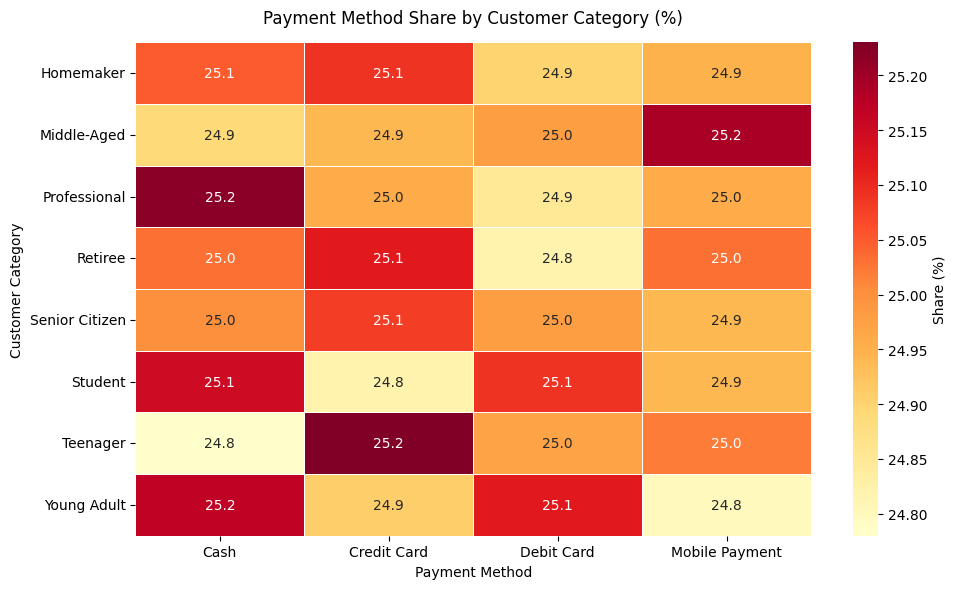

In [25]:
customer_payment = (raw_df
                    .groupby(['Customer_Category','Payment_Method'],as_index=False)['Total_Cost']
                    .sum()
                    .rename(columns={'Total_Cost':'Spend ($)'})
                    .sort_values(by=['Spend ($)','Customer_Category'],ascending=[False,True])
                    .assign(Total=lambda df: df.groupby('Customer_Category')['Spend ($)'].transform('sum'),
                            Percent=lambda df: round(df['Spend ($)']/df['Total']*100, 2)
                            )
                            .pivot(index='Customer_Category',columns='Payment_Method',values='Percent')
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(customer_payment, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Share (%)'})

ax.set_title('Payment Method Share by Customer Category (%)', pad=14)
ax.set_xlabel('Payment Method')
ax.set_ylabel('Customer Category')
plt.tight_layout()
plt.show()

**Inference**
- For each customer category, each payment type varies betweem [24.8%-25.2%]
- No particular inference can be drawn about preference of payment type for any of the customer categories
- May be an artefact of data being synthetic

In [26]:
## Average # products purchased per transaction by customer category
raw_df.groupby(['Store_Type']
                , as_index=False)['Total_Items'].mean()

,Store_Type,Total_Items
0,Convenience Store,5.505574
1,Department Store,5.495547
2,Pharmacy,5.498182
3,Specialty Store,5.508395
4,Supermarket,5.485767
5,Warehouse Club,5.482233


**Inference**
- For each store type, ~5 items are purchaced 
- No particular inference can be drawn about preference 
- May be an artefact of data being synthetic

### PROMOTIONS & DISCOUNTS

In [27]:

(
    raw_df
    .groupby(['Discount_Applied'],as_index=False, dropna=False)['Total_Cost']
    .mean()
    .sort_values(by='Total_Cost',ascending=False)
    .rename(columns={'Total_Cost': 'Avg_Spend ($)'})
    .head(5)
)

,Discount_Applied,Avg_Spend ($)
1,True,52.486915
0,False,52.423512


In [28]:
pd.merge(
    (
    raw_df
        .groupby(['Promotion'],as_index=False, dropna=False)['Total_Items']
        .mean()
        .sort_values(by='Total_Items',ascending=False)
        .head(5)
    ), 
    (
        raw_df
            .groupby(['Promotion'],as_index=False, dropna=False)['Total_Cost']
            .mean()
            .sort_values(by='Total_Cost',ascending=False)
            .rename(columns={'Total_Cost': 'Avg_Spend ($)'})
            .head(5)
    ), 
    on='Promotion'
)

,Promotion,Total_Items,Avg_Spend ($)
0,Discount on Selected Items,5.501248,52.380922
1,BOGO (Buy One Get One),5.494351,52.418500
2,NaN,5.492228,52.565973


**Inference**
- Average spend ~$52 regardless of discounts
- Average number of items purchaced on promotions is ~5.5 with average value ~$52

### SEASONALITY

In [29]:
top5_per_season = (df_long
 .groupby(['Season' ,'product_cleansed'])['Transaction_ID']
 .nunique()
 .reset_index()
 .sort_values(['Season','Transaction_ID'], ascending=[True, False])
 .groupby(['Season'])
 .head(5)
)
top5_per_season

,Season,product_cleansed,Transaction_ID
73,Autumn,Toothpaste,16109
35,Autumn,Ironing Board,8430
2,Autumn,BBQ Sauce,8359
11,Autumn,Carrots,8356
40,Autumn,Light Bulbs,8348
154,Spring,Toothpaste,19934
152,Spring,Tomatoes,10263
113,Spring,Ice Cream,10233
117,Spring,Jam,10215
87,Spring,Beef,10201


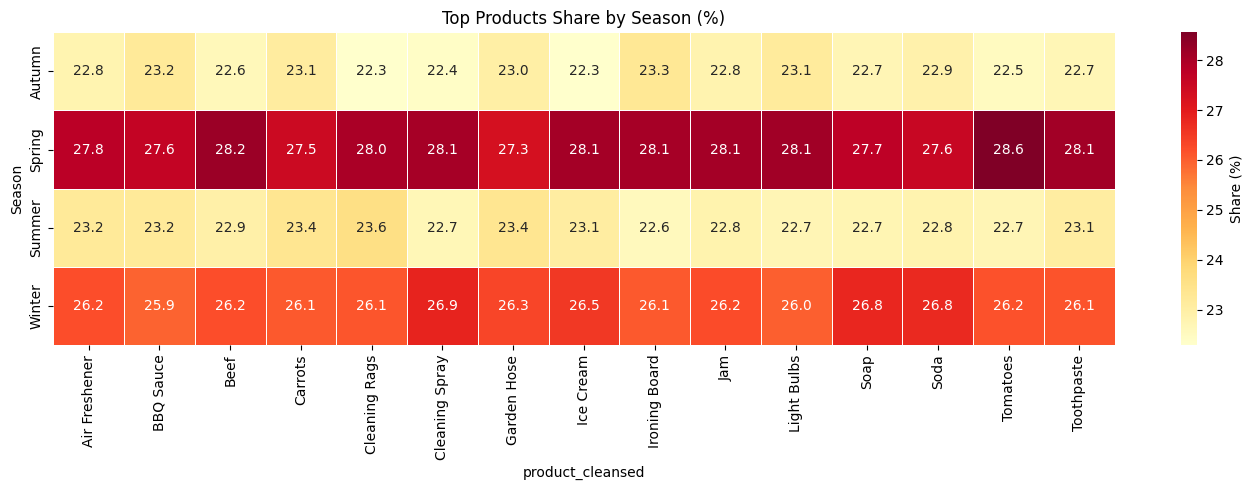

In [30]:
# Union of all top products across seasons
top_products = top5_per_season['product_cleansed'].unique()

pivot_product = (df_long[df_long['product_cleansed'].isin(top_products)]
 .groupby(['Season', 'product_cleansed'])['Transaction_ID']
 .sum()
 .unstack()
 .apply(lambda x: (x / x.sum() * 100).round(2))
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_product, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Share (%)'})
ax.set_title('Top Products Share by Season (%)')
plt.tight_layout()
plt.show()

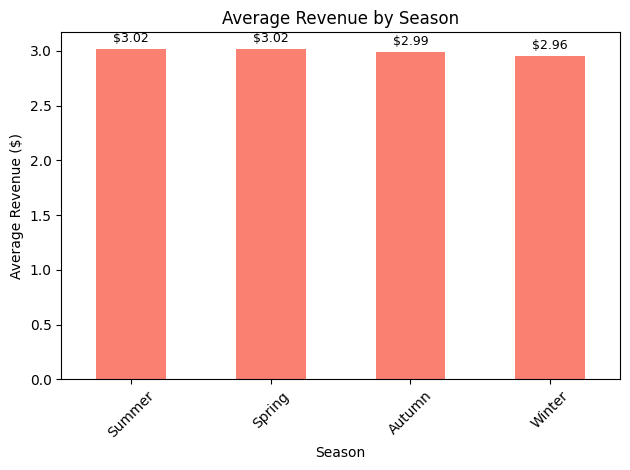

In [31]:
season_revenue_avg = (season_revenue
                      .groupby('Season')['Total_Revenue_M']
                      .mean()
                      .sort_values(ascending=False)
                      )

ax = season_revenue_avg.plot(x='Season', y='Total_Revenue_M', kind='bar', color='salmon')
plt.title('Average Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Average Revenue ($)')
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='$%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

### VISUALISATION DASHBOARD

,City,Unique_Transactions
1,Boston,100566
3,Dallas,100559
9,Seattle,100167
2,Chicago,100059
4,Houston,100050


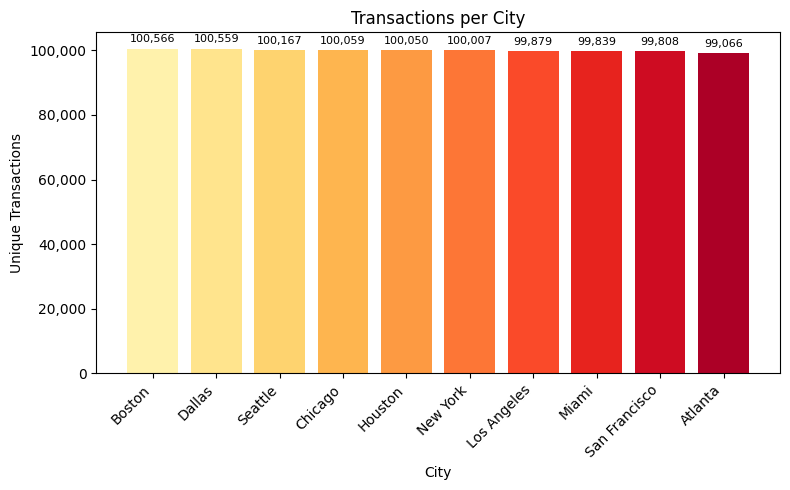

In [32]:
transactions_per_city = (raw_df
                         .groupby('City', as_index=False)['Transaction_ID']
                            .nunique()
                            .rename(columns={'Transaction_ID': 'Unique_Transactions'})
                            .sort_values(by='Unique_Transactions', ascending=False)
)
display(transactions_per_city.head())

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(transactions_per_city['City'], transactions_per_city['Unique_Transactions'],
       color=sns.color_palette('YlOrRd', len(transactions_per_city)))

ax.set_title('Transactions per City')
ax.set_xlabel('City')
ax.set_ylabel('Unique Transactions')
ax.bar_label(ax.containers[0],
             labels=[f"{v:,.0f}" for v in transactions_per_city['Unique_Transactions']],
             padding=3, fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

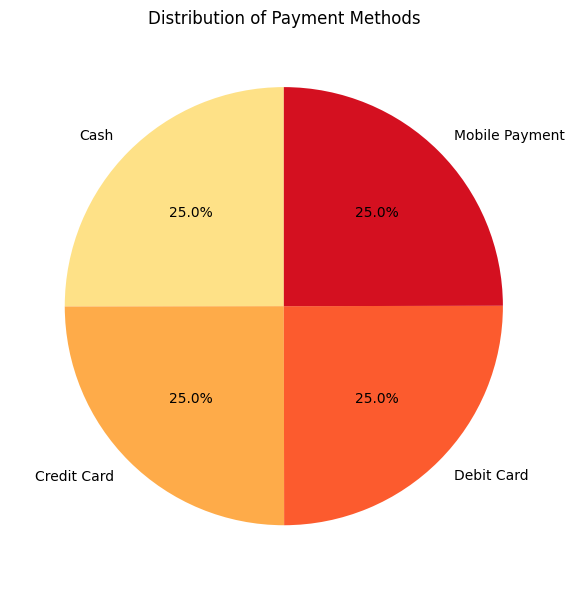

In [33]:
payment_dist = (raw_df
                .groupby('Payment_Method')['Transaction_ID']
                .nunique()
                )

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(payment_dist.values,
       labels=payment_dist.index,
       autopct=lambda p: f'{p:.1f}%',
       colors=sns.color_palette('YlOrRd', len(payment_dist)),
       startangle=90)

ax.set_title('Distribution of Payment Methods')
plt.tight_layout()
plt.show()

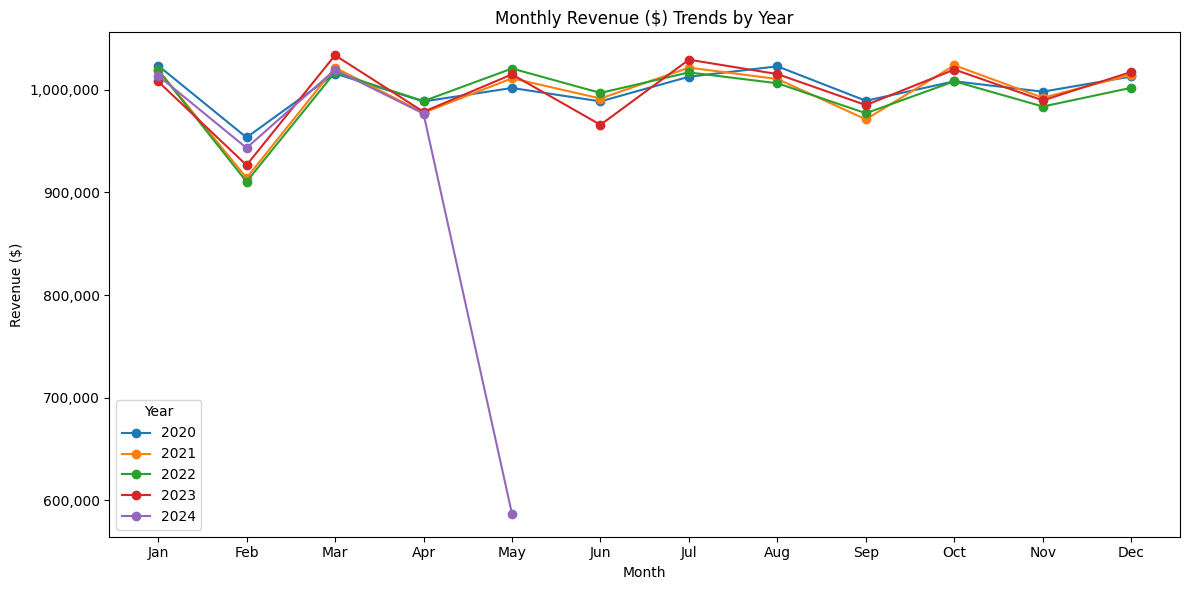

In [34]:
monthly_revenue = (raw_df
                   .groupby(['Year', 'Month'], as_index=False)['Total_Cost']
                   .sum()
                   .rename(columns={'Total_Cost': 'Revenue'})
                   )

fig, ax = plt.subplots(figsize=(12, 6))
for year, grp in monthly_revenue.groupby('Year'):
    ax.plot(grp['Month'], grp['Revenue'], marker='o', label=str(year))

ax.set_title('Monthly Revenue ($) Trends by Year')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(title='Year')
plt.tight_layout()
plt.show()